# **MNIST - Measures of Quality**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
import sys, os
sys.path.append(os.getcwd())

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


In [3]:
!pip install torchmetrics
!pip install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.8 MB/s eta 0:00:00


## Imports

In [4]:
import os
import sys

import torch
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Subset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Resize, Compose

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

from src.metrics import (
    to_01_range,
    inception_uint8,
    load_saved_samples,
    bpd_probability_flow_ode,
)

from src.score_model import ScoreNet
from src.brownian import make_bm_process_functions, make_bm_probability_flow_drift
from src.ou_schedules import make_ou_process_functions, make_ou_probability_flow_drift

## Basic configuration

In [5]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

_ = torch.manual_seed(123)

Device: cuda
Number of threads: 6


## Load Dataset

In [6]:
# Addd Resize((32, 32)) to ensure dimensions are powers of 2
transform = Compose([
    Resize((32, 32)),
    ToTensor(),
    Normalize((0.5,), (0.5,)) # It's also advisable to normalize here
])

# Dataset MNIST
data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Create a subset dataset composed only of one digit
digit = 3
indices_digit = torch.where(data.targets == digit)[0]
data_train = Subset(data, indices_digit)

print(type(data_train))
print("Number of images:", len(data_train))

<class 'torch.utils.data.dataset.Subset'>
Number of images: 6131


## Measure models and samplers

In [7]:
models = [
    {
        "name": "bm + ode",
        "base_path": "./samples/mnist_bm",
        "sampler_key": "final_images_ode",
        "checkpoint_template": "./checkpoints/mnist_bm/checkpoint_mnist_bm_epoch{epoch}.pth",
        "process": "bm",
    },
    {
        "name": "ou + cosine + pc",
        "base_path": "./samples/mnist_ou_cosine",
        "sampler_key": "final_images_pc",
        "checkpoint_template": "./checkpoints/mnist_ou_cosine/checkpoint_ou_cosine_epoch{epoch}.pth",
        "process": "ou_cosine",
    },
]

epochs = [10, 20, 50, 100, 200, 500]

# BPD configuration
n_bpd_images = min(2000, len(data_train))
bpd_batch_size = 32
bpd_n_steps = 500
bpd_correction_bits = 7.0

results = []

for model in models:
    for epoch in epochs:
        sample_file = f"{model['base_path']}/final_images_epoch{epoch}.pt"
        checkpoint_path = model["checkpoint_template"].format(epoch=epoch)

        if not os.path.exists(sample_file):
            print(f"Skipping {model['name']} epoch {epoch}: sample file not found")
            continue

        if not os.path.exists(checkpoint_path):
            print(f"Skipping {model['name']} epoch {epoch}: checkpoint not found")
            continue

        # Load generated images
        generated_images = load_saved_samples(
            sample_file,
            sampler_key=model["sampler_key"],
        )

        generated_images_01 = to_01_range(
            generated_images,
            assume_minus1_1=True,
        )

        target_n = generated_images_01.shape[0]

        real_images = torch.stack([
            data_train[i][0] for i in range(target_n)
        ])

        real_images_01 = to_01_range(
            real_images,
            assume_minus1_1=True,
        )

        real_u8 = inception_uint8(real_images_01).to(device)
        generated_u8 = inception_uint8(generated_images_01).to(device)

        # FID
        fid_metric = FrechetInceptionDistance(
            feature=2048,
            normalize=False,
        ).to(device)

        fid_metric.update(real_u8, real=True)
        fid_metric.update(generated_u8, real=False)
        fid_value = fid_metric.compute().item()

        # IS
        is_metric = InceptionScore(normalize=False).to(device)
        is_metric.update(generated_u8)
        is_mean, is_std = is_metric.compute()

        # Load score model and probability flow drift for BPD
        if model["process"] == "bm":
            sigma = 25.0
            sched = make_bm_process_functions(sigma)

            score_model = ScoreNet(
                marginal_prob_std=sched["sigma_t"],
                in_channels=1,
                out_channels=1,
            ).to(device)

            state_dict = torch.load(checkpoint_path, map_location=device)
            score_model.load_state_dict(state_dict)
            score_model.eval()

            probability_flow_drift = make_bm_probability_flow_drift(
                diffusion_coefficient=sched["diffusion_coefficient"],
                score_model=score_model,
            )

            terminal_std = sched["sigma_t"](
                torch.tensor([1.0], device=device)
            ).item()

        elif model["process"] == "ou_cosine":
            sched = make_ou_process_functions("cosine")

            score_model = ScoreNet(
                marginal_prob_std=sched["sigma_t"],
                in_channels=1,
                out_channels=1,
            ).to(device)

            state_dict = torch.load(checkpoint_path, map_location=device)
            score_model.load_state_dict(state_dict)
            score_model.eval()

            probability_flow_drift = make_ou_probability_flow_drift(
                schedule_dict=sched,
                score_model=score_model,
            )

            terminal_std = sched["sigma_t"](
                torch.tensor([1.0], device=device)
            ).item()

        else:
            raise ValueError(f"Unknown process: {model['process']}")

        # BPD
        bpd_values = []

        for start in range(0, n_bpd_images, bpd_batch_size):
            end = min(start + bpd_batch_size, n_bpd_images)

            bpd_images = torch.stack([
                data_train[i][0] for i in range(start, end)
            ]).to(device)

            _, bpd_batch = bpd_probability_flow_ode(
                x_0=bpd_images,
                probability_flow_drift=probability_flow_drift,
                terminal_std=terminal_std,
                t_0=1.0e-3,
                t_end=1.0,
                n_steps=bpd_n_steps,
            )

            bpd_values.append(bpd_batch.detach().cpu())

        bpd_value = torch.cat(bpd_values).mean().item()
        bpd_value = bpd_value + bpd_correction_bits

        results.append({
            "model": model["name"],
            "epoch": epoch,
            "fid": round(fid_value, 4),
            "is_mean": round(is_mean.item(), 4),
            "is_std": round(is_std.item(), 4),
            "bpd_ode": round(bpd_value, 4),
        })


Evaluating bm + ode epoch 10...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 431MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



Evaluating bm + ode epoch 20...

Evaluating bm + ode epoch 50...

Evaluating bm + ode epoch 100...

Evaluating bm + ode epoch 200...

Evaluating bm + ode epoch 500...

Evaluating ou + cosine + pc epoch 10...

Evaluating ou + cosine + pc epoch 20...

Evaluating ou + cosine + pc epoch 50...

Evaluating ou + cosine + pc epoch 100...

Evaluating ou + cosine + pc epoch 200...

Evaluating ou + cosine + pc epoch 500...


## Show result

In [8]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(["fid", "epoch"]))

,model,epoch,fid,is_mean,is_std,bpd_ode
8,ou + cosine + pc,50,18.2313,1.6033,0.0301,1.7048
10,ou + cosine + pc,200,37.7622,1.5635,0.0512,1.0434
11,ou + cosine + pc,500,44.3234,1.4402,0.0197,1.3044
9,ou + cosine + pc,100,44.6639,1.5834,0.0396,1.4774
7,ou + cosine + pc,20,59.6231,1.7904,0.0425,2.8291
1,bm + ode,20,100.1155,1.7973,0.0484,3.2172
4,bm + ode,200,108.0395,1.6029,0.0298,2.8036
3,bm + ode,100,116.4401,1.6553,0.0463,2.7492
5,bm + ode,500,119.1333,1.4506,0.0234,2.7035
2,bm + ode,50,124.1898,1.6341,0.0438,2.7908


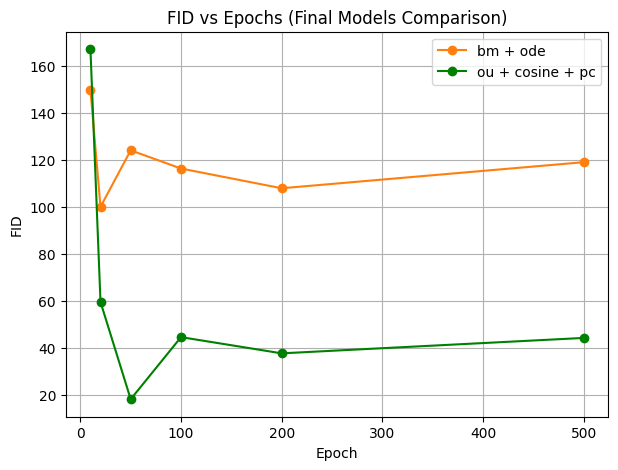

In [9]:
plt.figure(figsize=(7, 5))

colors = {
    "bm + ode": "C1",
    "ou + cosine + pc": "g",
}

for model_name in results_df["model"].unique():
    subset = results_df[results_df["model"] == model_name]
    plt.plot(
        subset["epoch"],
        subset["fid"],
        marker="o",
        label=model_name,
        color=colors.get(model_name, "black"),
    )

plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID vs Epochs (Final Models Comparison)")
plt.legend()
plt.grid(True)
plt.show()

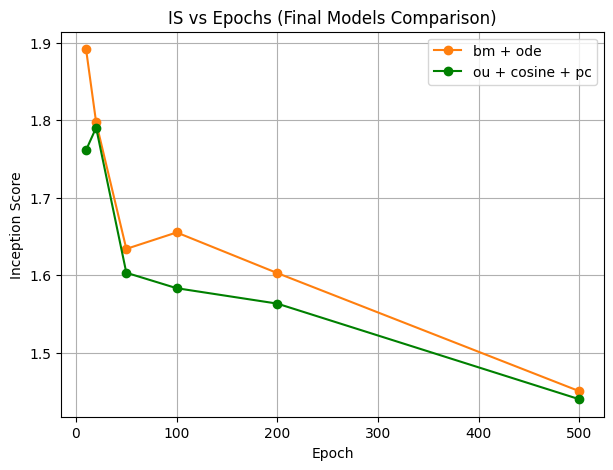

In [10]:
plt.figure(figsize=(7, 5))

for model_name in results_df["model"].unique():
    subset = results_df[results_df["model"] == model_name]
    plt.plot(
        subset["epoch"],
        subset["is_mean"],
        marker="o",
        label=model_name,
        color=colors.get(model_name, "black"),
    )

plt.xlabel("Epoch")
plt.ylabel("Inception Score")
plt.title("IS vs Epochs (Final Models Comparison)")
plt.legend()
plt.grid(True)
plt.show()

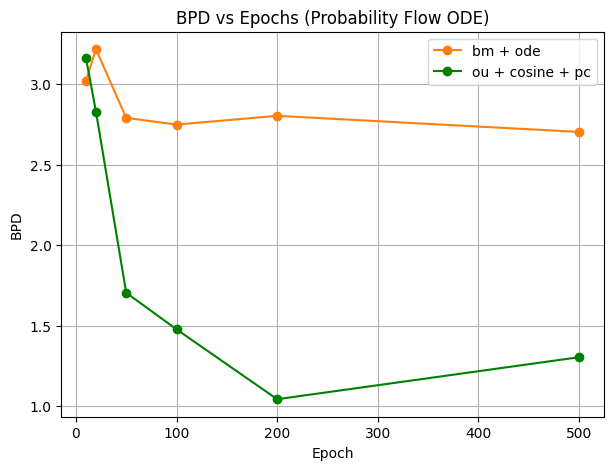

In [11]:
plt.figure(figsize=(7, 5))

for model_name in results_df["model"].unique():
    subset = results_df[results_df["model"] == model_name]
    plt.plot(
        subset["epoch"],
        subset["bpd_ode"],
        marker="o",
        label=model_name,
        color=colors.get(model_name, "black"),
    )

plt.xlabel("Epoch")
plt.ylabel("BPD")
plt.title("BPD vs Epochs (Probability Flow ODE)")
plt.legend()
plt.grid(True)
plt.show()